# California Housing 树模型基准

本 Notebook 在原有线性回归项目上增加决策树、随机森林和直方图梯度提升。三类模型共享相同的数据划分和派生特征，所有缺失值处理与类别编码都在交叉验证管道内完成。

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from housing_regression import load_data, split_data
from tree_models import build_search, summarize
sns.set_theme(style="whitegrid")

## 1. 使用与线性模型相同的数据划分

In [2]:
X_train, X_test, y_train, y_test = split_data(load_data())
pd.DataFrame(
    {"样本数": [len(X_train), len(X_test)], "特征数": [X_train.shape[1], X_test.shape[1]]},
    index=["开发集", "测试集"],
)

,样本数,特征数
开发集,16512,15
测试集,4128,15


## 2. 仅在开发集上执行模型与超参数选择

In [3]:
search = build_search(X_train)
search.fit(X_train, y_train)
comparison = summarize(search)
comparison[["model", "CV_RMSE"]].round(0)

,model,CV_RMSE
1,HistGradientBoostingRegressor,45594.0
2,RandomForestRegressor,48258.0
0,DecisionTreeRegressor,57982.0


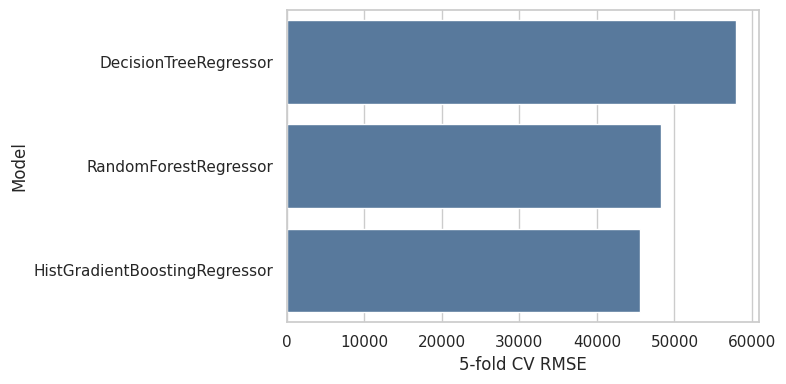

In [4]:
plt.figure(figsize=(8, 4))
plot_data = comparison.sort_values("CV_RMSE", ascending=False)
sns.barplot(data=plot_data, x="CV_RMSE", y="model", color="#4c78a8")
plt.xlabel("5-fold CV RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 3. 最佳模型的独立测试评估

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

prediction = search.best_estimator_.predict(X_test)
metrics = {
    "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
    "MAE": mean_absolute_error(y_test, prediction),
    "R2": r2_score(y_test, prediction),
}
print("最终模型：", type(search.best_estimator_.named_steps["model"]).__name__)
pd.DataFrame([metrics]).round(3)

最终模型： HistGradientBoostingRegressor


,RMSE,MAE,R2
0,42865.152,28426.734,0.859


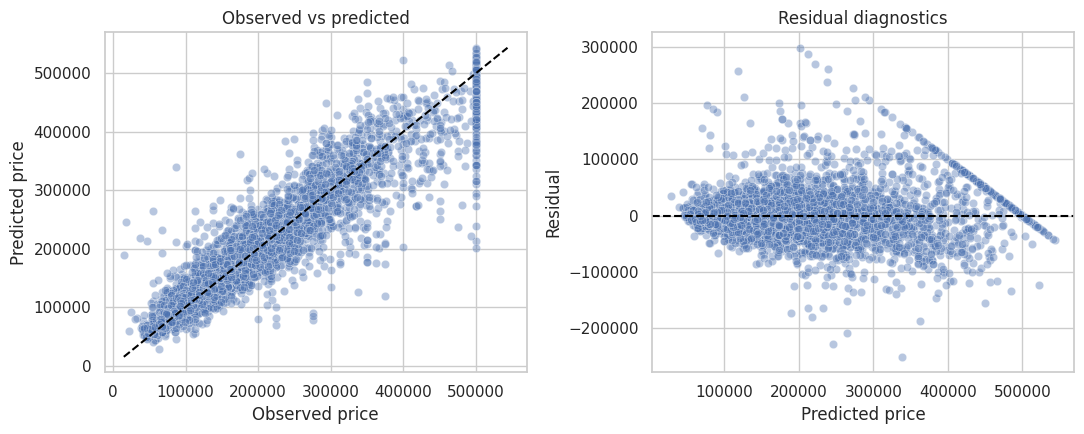

In [6]:
residual = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(x=y_test, y=prediction, alpha=0.4, ax=axes[0])
limits = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(xlabel="Observed price", ylabel="Predicted price", title="Observed vs predicted")
sns.scatterplot(x=prediction, y=residual, alpha=0.4, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(xlabel="Predicted price", ylabel="Residual", title="Residual diagnostics")
fig.tight_layout()
plt.show()

## 结论

HistGradientBoosting 的测试 RMSE 为约 **42,865**、R² 为约 **0.859**，显著优于原线性模型的 RMSE 66,349。主要收益来自树模型对非线性关系和特征交互的表达能力；独立决策树明显落后于集成方法。